In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
block_size = 3 # context length - how many charachters do we take to predict the next one

def build_dataset(words):
    
    X, Y = [], []
    for w in words:

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

X_train, Y_train = build_dataset(words[:n1])
X_valid, Y_valid = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

In [6]:
hidden_layer_size = 200
embedding_dim = 10
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, embedding_dim), generator=g)
W1 = torch.randn((block_size * embedding_dim, hidden_layer_size), generator=g)
b1 = torch.randn(hidden_layer_size, generator=g)
W2 = torch.randn((hidden_layer_size, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [7]:
print('parameters count', sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

parameters count 11897


epoch 0 learning_rate 0.3 loss 2.972792863845825
epoch 1 learning_rate 0.1 loss 2.211514711380005
epoch 2 learning_rate 0.1 loss 2.295156478881836
epoch 3 learning_rate 0.03 loss 2.2937166690826416
epoch 4 learning_rate 0.03 loss 2.2556490898132324
epoch 5 learning_rate 0.01 loss 2.0245378017425537
epoch 6 learning_rate 0.01 loss 2.1421468257904053


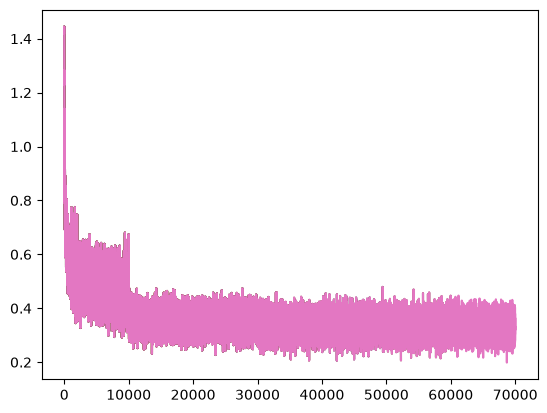

In [8]:
import math

from matplotlib.pyplot import plot
from torch import log10

iterations = 10000
batch_size = 64

#lre = torch.linspace(-3, 0, iterations)
#lrs = 10**lre
lrs = [0.3, 0.1, 0.1, 0.03, 0.03, 0.01, 0.01]
epochs = len(lrs)

steps, losses = [], []
lri, lsi = [], []
for epoch in range(epochs):
    learning_rate = lrs[epoch]

    for iter in range(iterations):

        # batch construction
        ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)

        # forward pass
        emb = C[X_train[ix]]
        h = torch.tanh(emb.view(-1, block_size * embedding_dim) @ W1 + b1)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Y_train[ix])
        #print(iter, loss.item())

        # backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # update
        for p in parameters:
            p.data += -learning_rate * p.grad

        # to plot iteration vs loss
        steps.append(iter + epoch * iterations)
        losses.append(loss.log10().item())

        # to plot learning rate vs loss
        lri.append(math.log10(learning_rate))
        lsi.append(loss.log10().item())

    print('epoch', epoch, 'learning_rate', learning_rate, 'loss', loss.item())

    plot(steps, losses)


In [9]:
emb = C[X_valid]
h = torch.tanh(emb.view(-1, block_size * embedding_dim) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_valid)
print('valid loss', loss.item())

valid loss 2.1919219493865967


In [10]:
# sampling from the trained neural net
g = torch.Generator().manual_seed(2147483647 + 10)

for i in range(25):

    out = []
    context = [0] * block_size
    
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))
        


carlah.
aar.
harif.
jari.
reh.
cassanden.
jazhnen.
delynn.
jarqui.
ner.
kiah.
maiir.
kaleigh.
ham.
porriessan.
shovora.
jadbi.
watelogiefryxi.
frae.
pirran.
edde.
oia.
gilfahysta.
alaas.
benjamsya.
